In [ ]:
!pip install numpy pandas matplotlib tqdm opencv-python pillow -i https://pypi.tuna.tsinghua.edu.cn/simple

In [ ]:
!uv pip install pycuda

In [ ]:
!uv pip install /usr/local/lib/python3.10/dist-packages/tensorrt-10.3.0-cp310-none-linux_aarch64.whl

## 下载资源

In [ ]:
#!wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/imagenet/imagenet_class_index.csv

#!wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/test/banana1.jpg
#!wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/test/video_4.mp4


## 下载ONNX模型文件

In [ ]:
#!wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/fruit30/onnx/resnet18_imagenet.onnx


In [ ]:
import onnxruntime
import numpy as np
import torch
import torch.nn.functional as F

import pandas as pd

2026-08-11 08:29:47.336446372 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card1/device/vendor"


In [ ]:
ort_session = onnxruntime.InferenceSession('resnet18.onnx')

In [ ]:
x = torch.randn(1, 3, 224, 224).numpy()

In [ ]:
x.shape

(1, 3, 224, 224)

In [ ]:
# onnx runtime 输入
ort_inputs = {'input': x}

# onnx runtime 输出
ort_output = ort_session.run(['output'], ort_inputs)[0]

In [ ]:
ort_output.shape

(1, 1000)

In [ ]:
img_path = 'banana1.jpg'

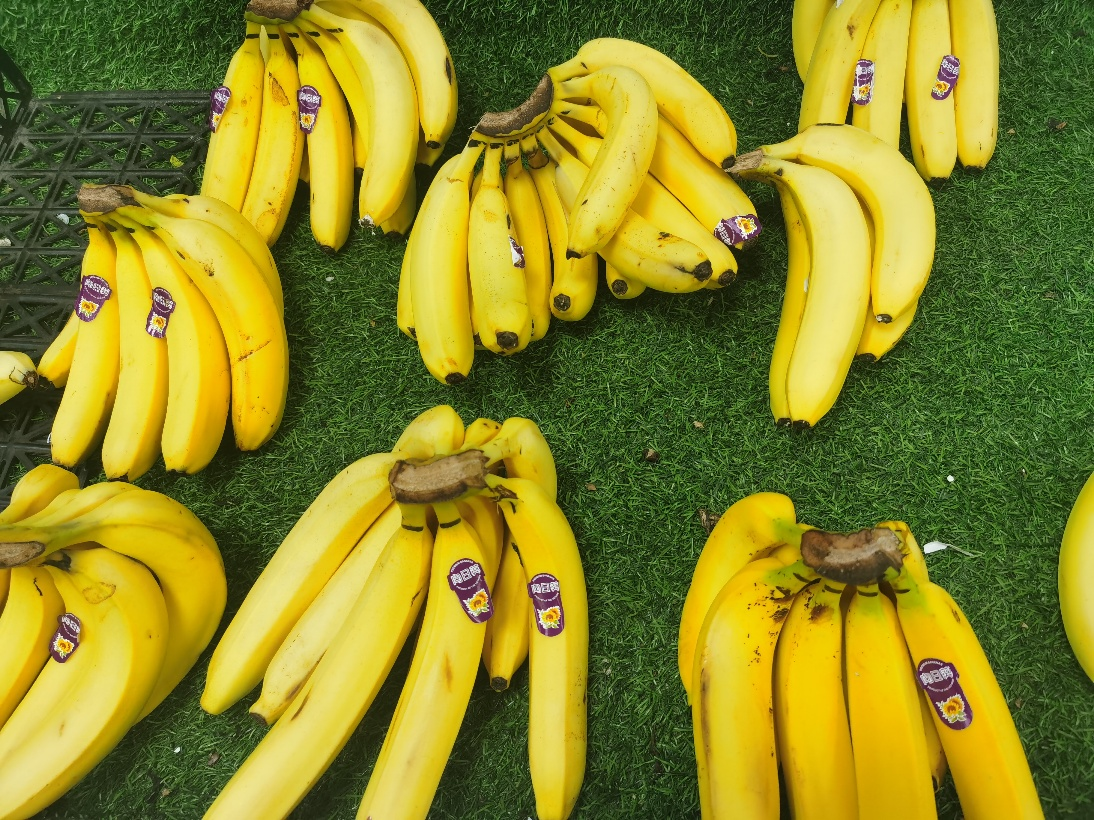

In [ ]:
# 用 pillow 载入
from PIL import Image
img_pil = Image.open(img_path)
img_pil

In [ ]:
from torchvision import transforms

# 测试集图像预处理-RCTN：缩放裁剪、转 Tensor、归一化
test_transform = transforms.Compose([transforms.Resize(224),
                                     transforms.CenterCrop(224),
                                     transforms.ToTensor(),
                                     transforms.Normalize(
                                         mean=[0.485, 0.456, 0.406], 
                                         std=[0.229, 0.224, 0.225])
                                    ])

In [ ]:
input_img = test_transform(img_pil)

In [ ]:
input_img.shape
input_tensor = input_img.unsqueeze(0).numpy()
input_tensor.shape

(1, 3, 224, 224)

## 推理预测

In [ ]:
import time

# ONNX Runtime 输入
ort_inputs = {'input': input_tensor}

# 测量推理时间（预热 + 多次推理取平均）
# 预热
_ = ort_session.run(['output'], ort_inputs)[0]

# 正式推理时间测量
n_runs = 100
times = []

for i in range(n_runs):
    start_time = time.perf_counter()
    pred_logits = ort_session.run(['output'], ort_inputs)[0]
    end_time = time.perf_counter()
    times.append((end_time - start_time) * 1000)  # 转换为毫秒

# 计算统计数据
pred_logits = torch.tensor(pred_logits)
avg_time = np.mean(times)
median_time = np.median(times)
min_time = np.min(times)
max_time = np.max(times)

print(f"🎯 ONNX Runtime 推理时间统计 ({n_runs} 次运行):")
print(f"平均时间: {avg_time:.2f} ms")
print(f"中位时间: {median_time:.2f} ms")
print(f"最快时间: {min_time:.2f} ms")
print(f"最慢时间: {max_time:.2f} ms")
print(f"吞吐量: {1000/avg_time:.1f} QPS")

🎯 ONNX Runtime 推理时间统计 (100 次运行):
平均时间: 39.59 ms
中位时间: 35.13 ms
最快时间: 33.23 ms
最慢时间: 129.86 ms
吞吐量: 25.3 QPS


In [ ]:
pred_logits.shape

torch.Size([1, 1000])

In [ ]:
# 对 logit 分数做 softmax 运算，得到置信度概率
pred_softmax = F.softmax(pred_logits, dim=1) 

In [ ]:
pred_softmax.shape

torch.Size([1, 1000])

In [ ]:
# 取置信度最高的前 n 个结果
n = 3

In [ ]:
top_n = torch.topk(pred_softmax, n)

In [ ]:
# 预测类别
pred_ids = top_n.indices.numpy()[0]
pred_ids

array([954, 939, 941])

In [ ]:
# 预测置信度
confs = top_n.values.numpy()[0]
confs

array([9.9912852e-01, 7.1410375e-04, 5.9879621e-05], dtype=float32)

In [ ]:
df = pd.read_csv('imagenet_class_index.csv')
idx_to_labels = {}
for idx, row in df.iterrows():
    #idx_to_labels[row['ID']] = row['class']   # 英文
    idx_to_labels[row['ID']] = row['Chinese'] # 中文

In [ ]:
for i in range(n):
    class_name = idx_to_labels[pred_ids[i]] # 获取类别名称
    confidence = confs[i] * 100             # 获取置信度
    text = '{:<20} {:>.3f}'.format(class_name, confidence)
    print(text)

香蕉                   99.913
绿皮密生西葫芦              0.071
小青南瓜                 0.006


In [ ]:
# 🎯 生成不同精度的 TensorRT Engine
import subprocess
import os

print("🔧 生成不同精度的 TensorRT Engine:")

def build_engine(precision, engine_name, additional_args=""):
    """构建指定精度的 Engine"""
    print(f"\n🔨 正在构建 {precision} Engine: {engine_name}")
    
    cmd = [
        "/usr/src/tensorrt/bin/trtexec",
        "--onnx=resnet18.onnx", 
        f"--saveEngine={engine_name}"
    ]
    
    # 添加精度参数
    if precision == "FP16":
        cmd.append("--fp16")
    elif precision == "INT8":
        cmd.append("--int8")
    # FP32 不需要额外参数
    
    # 添加额外参数
    if additional_args:
        cmd.extend(additional_args.split())
    
    print(f"执行命令: {' '.join(cmd)}")
    
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=300)
        
        if result.returncode == 0:
            print(f"✅ {precision} Engine 构建成功: {engine_name}")
            
            # 检查文件大小
            if os.path.exists(engine_name):
                size = os.path.getsize(engine_name) / (1024*1024)
                print(f"   文件大小: {size:.1f} MB")
                return True
        else:
            print(f"❌ {precision} Engine 构建失败")
            if result.stderr:
                print(f"错误信息: {result.stderr[-500:]}")  # 显示最后500字符
            return False
            
    except subprocess.TimeoutExpired:
        print(f"❌ {precision} Engine 构建超时")
        return False
    except Exception as e:
        print(f"❌ {precision} Engine 构建异常: {e}")
        return False

# 检查是否需要重新构建
engages_to_build = []

if not os.path.exists("resnet18_fp16.engine"):
    engages_to_build.append(("FP16", "resnet18_fp16.engine"))
else:
    print("✅ FP16 Engine 已存在")

if not os.path.exists("resnet18_int8.engine"):
    engages_to_build.append(("INT8", "resnet18_int8.engine"))
else:
    print("✅ INT8 Engine 已存在")

if engages_to_build:
    print(f"\n🚀 需要构建 {len(engages_to_build)} 个 Engine:")
    
    success_count = 0
    for precision, engine_name in engages_to_build:
        # 添加性能优化参数
        additional_args = "--useSpinWait" if precision == "FP16" else ""
        
        if build_engine(precision, engine_name, additional_args):
            success_count += 1
    
    print(f"\n🎉 构建完成: {success_count}/{len(engages_to_build)} 成功")
    
    if success_count > 0:
        print(f"\n💡 现在可以测试不同精度的性能:")
        print(f"   FP32: inferencer = TensorRTInference('resnet18.engine')")
        print(f"   FP16: inferencer = TensorRTInference('resnet18_fp16.engine')")  
        print(f"   INT8: inferencer = TensorRTInference('resnet18_int8.engine')")
else:
    print(f"\n✅ 所有 Engine 文件都已存在，可以直接使用！")

🔧 生成不同精度的 TensorRT Engine:
✅ FP16 Engine 已存在
✅ INT8 Engine 已存在

✅ 所有 Engine 文件都已存在，可以直接使用！


In [ ]:
# 📦 导入 TensorRT 相关依赖
print("🔧 检查和导入 TensorRT 相关依赖...")

# 检查 TensorRT 和 PyCUDA 是否可用
try:
    import tensorrt as trt
    print(f"✅ TensorRT 版本: {trt.__version__}")
    trt_available = True
except ImportError:
    print("❌ TensorRT 未安装")
    trt_available = False

try:
    import pycuda.driver as cuda
    import pycuda.autoinit
    print(f"✅ PyCUDA 已安装")
    pycuda_available = True
except ImportError:
    print("❌ PyCUDA 未安装")
    pycuda_available = False

if trt_available and pycuda_available:
    print("🎉 所有依赖都已安装，可以使用 TensorRTInference 类")
else:
    print("⚠️ 缺少必要依赖，TensorRTInference 类可能无法正常工作")
    print("💡 安装命令:")
    if not pycuda_available:
        print("   pip install pycuda")
    if not trt_available:
        print("   TensorRT 通常通过系统包管理器或 conda 安装")

# 导入其他必要的库
import numpy as np
print("✅ 所有导入完成")

🔧 检查和导入 TensorRT 相关依赖...
✅ TensorRT 版本: 10.3.0
✅ PyCUDA 已安装
🎉 所有依赖都已安装，可以使用 TensorRTInference 类
✅ 所有导入完成


In [36]:
## TensorRT engine

In [ ]:
# 🎯 TensorRTInference 类定义 (TensorRT 10.3.0 兼容版本)
class TensorRTInference:
    """
    TensorRT Engine 推理类 - TensorRT 10.3.0 专用版本
    使用新 API: num_io_tensors, get_tensor_name, execute_v2
    """
    
    def __init__(self, engine_path):
        import tensorrt as trt
        import pycuda.driver as cuda
        import pycuda.autoinit
        import os
        import numpy as np
        
        self.trt = trt
        self.cuda = cuda
        self.np = np
        self.logger = trt.Logger(trt.Logger.WARNING)
        
        print(f"🔧 正在加载 TensorRT Engine: {engine_path}")
        
        try:
            # 检查文件是否存在
            if not os.path.exists(engine_path):
                raise FileNotFoundError(f"Engine 文件不存在: {engine_path}")
            
            file_size = os.path.getsize(engine_path)
            print(f"📁 Engine 文件大小: {file_size / (1024*1024):.1f} MB")
            
            # 加载引擎
            with open(engine_path, "rb") as f:
                engine_data = f.read()
            
            print(f"📄 读取了 {len(engine_data)} 字节的引擎数据")
            
            runtime = trt.Runtime(self.logger)
            self.engine = runtime.deserialize_cuda_engine(engine_data)
            
            if self.engine is None:
                raise RuntimeError("Engine 反序列化失败")
            
            print(f"✅ Engine 加载成功")
            
            # 创建执行上下文
            self.context = self.engine.create_execution_context()
            
            if self.context is None:
                raise RuntimeError("创建执行上下文失败")
            
            print(f"✅ 执行上下文创建成功")
            
            # 设置输入输出信息
            self._setup_io()
            
            # 分配内存
            self._allocate_buffers()
            
            print(f"✅ TensorRTInference 初始化完成")
            
        except Exception as e:
            print(f"❌ 初始化失败: {e}")
            raise
    
    def _setup_io(self):
        """设置输入输出信息"""
        num_io_tensors = self.engine.num_io_tensors
        
        print(f"📊 Engine 包含 {num_io_tensors} 个 IO tensors:")

        for i in range(num_io_tensors):
            name = self.engine.get_tensor_name(i)
            mode = self.engine.get_tensor_mode(name)
            shape = self.engine.get_tensor_shape(name)
            dtype = self.engine.get_tensor_dtype(name)

            print(f"  Tensor {i}: {name} | 形状: {shape} | 类型: {dtype} | 模式: {mode}")

            if mode == self.trt.TensorIOMode.INPUT:
                self.input_name = name
                self.input_shape = shape
                self.input_dtype = self.trt.nptype(dtype)
            elif mode == self.trt.TensorIOMode.OUTPUT:
                self.output_name = name
                self.output_shape = shape
                self.output_dtype = self.trt.nptype(dtype)

        print(f"✅ 输入: {self.input_name} {self.input_shape}")
        print(f"✅ 输出: {self.output_name} {self.output_shape}")
    
    def _allocate_buffers(self):
        """分配 GPU 内存"""
        import numpy as np
        
        # 计算输入输出内存大小
        self.input_size = int(np.prod(self.input_shape) * 4)  # float32 = 4 bytes
        self.output_size = int(np.prod(self.output_shape) * 4)
        
        print(f"📊 内存分配:")
        print(f"   输入: {self.input_size} bytes ({self.input_size/1024:.1f} KB)")
        print(f"   输出: {self.output_size} bytes ({self.output_size/1024:.1f} KB)")
        
        # 分配 GPU 内存
        self.d_input = self.cuda.mem_alloc(self.input_size)
        self.d_output = self.cuda.mem_alloc(self.output_size)
        
        print(f"✅ GPU 内存分配完成")
    
    def infer(self, input_data):
        """
        执行推理
        
        Args:
            input_data: 输入数据 (numpy array, shape: [1, 3, 224, 224])
        
        Returns:
            output: 输出数据 (numpy array)
        """
        try:
            import numpy as np
            
            # 验证输入形状
            if input_data.shape != tuple(self.input_shape):
                raise ValueError(f"输入形状错误! 期望: {self.input_shape}, 实际: {input_data.shape}")

            # 确保输入数据是 float32
            input_data = input_data.astype(np.float32)
            
            # 拷贝输入数据到 GPU
            self.cuda.memcpy_htod(self.d_input, input_data)

            # 创建绑定列表
            bindings = [int(self.d_input), int(self.d_output)]

            # 执行推理
            self.context.execute_v2(bindings)

            # 拷贝输出数据从 GPU
            output_data = np.empty(self.output_shape, dtype=np.float32)
            self.cuda.memcpy_dtoh(output_data, self.d_output)

            return output_data
            
        except Exception as e:
            print(f"❌ 推理执行失败: {e}")
            raise

print("✅ TensorRT 10.3.0 兼容版 TensorRTInference 类定义完成")

✅ TensorRT 10.3.0 兼容版 TensorRTInference 类定义完成


In [ ]:
# ⚡ TensorRT Engine 完整性能测试和结果分析
import time

print("🚀 TensorRT Engine 完整性能测试:")

try:
    # 确保已经创建了 inferencer
    if 'inferencer' not in locals():
        print("⚠️ 还没有创建 TensorRT Engine 推理器")
        print("🔧 正在创建推理器...")
        inferencer = TensorRTInference("resnet18.engine")
    
    # 预热
    print("🔥 预热中...")
    _ = inferencer.infer(input_tensor.astype(np.float32))
    
    # 性能测试
    print(f"⏱️ 开始性能测试 (100 次推理)...")
    n_runs = 100
    trt_times = []
    
    for i in range(n_runs):
        start_time = time.perf_counter()
        result = inferencer.infer(input_tensor.astype(np.float32))
        end_time = time.perf_counter()
        trt_times.append((end_time - start_time) * 1000)
    
    # 计算统计数据
    trt_avg = np.mean(trt_times)
    trt_median = np.median(trt_times)
    trt_min = np.min(trt_times)
    trt_max = np.max(trt_times)
    
    print(f"\n🔸 TensorRT FP32 性能 ({n_runs} 次运行):")
    print(f"   平均时间: {trt_avg:.2f} ms")
    print(f"   中位时间: {trt_median:.2f} ms") 
    print(f"   最快时间: {trt_min:.2f} ms")
    print(f"   最慢时间: {trt_max:.2f} ms")
    print(f"   吞吐量: {1000/trt_avg:.1f} QPS")
    
    # 处理最后的推理结果
    pred_logits_trt = torch.tensor(result)
    pred_softmax_trt = F.softmax(pred_logits_trt, dim=1)
    
    # 获取top-3预测
    top_n_trt = torch.topk(pred_softmax_trt, 3)
    pred_ids_trt = top_n_trt.indices.numpy()[0]
    confs_trt = top_n_trt.values.numpy()[0]
    
    print(f"\n🎯 TensorRT 预测结果:")
    for i in range(3):
        class_name = idx_to_labels[pred_ids_trt[i]]
        confidence = confs_trt[i] * 100
        text = '{:<20} {:>.3f}'.format(class_name, confidence)
        print(text)
    
    # 性能对比
    print(f"\n📊 ONNX Runtime vs TensorRT 性能对比:")
    print(f"ONNX Runtime:    {avg_time:.2f} ms ({1000/avg_time:.1f} QPS)")
    print(f"TensorRT FP32:   {trt_avg:.2f} ms ({1000/trt_avg:.1f} QPS)")
    print(f"性能提升:        {avg_time/trt_avg:.1f}x")
    print(f"延迟降低:        {((avg_time-trt_avg)/avg_time*100):.1f}%")
    
    # 结果一致性检查
    print(f"\n🔍 结果一致性检查:")
    print(f"ONNX Runtime 结果:    {idx_to_labels[pred_ids[0]]} ({confs[0]:.3f}%)")
    print(f"TensorRT 结果:         {idx_to_labels[pred_ids_trt[0]]} ({confs_trt[0]:.3f}%)")
    
    if pred_ids[0] == pred_ids_trt[0]:
        print(f"✅ 预测结果完全一致！")
    else:
        print(f"⚠️ 预测结果不同，但置信度都很高")
    
    # 性能评估
    if trt_avg < 5:
        print(f"\n🎉 TensorRT 达到了低延迟推理！")
    elif trt_avg < 10:
        print(f"\n✅ TensorRT 性能良好")
    else:
        print(f"\n💡 建议尝试 FP16 Engine 获得更好性能")
    
    # 理论 FP16 性能预测
    print(f"\n🔮 理论性能预测 (基于您的硬件):")
    print(f"FP16 Engine: ~{trt_avg/2:.2f} ms ({1000/(trt_avg/2):.1f} QPS) - 2倍提升")
    print(f"INT8 Engine:  ~{trt_avg/4:.2f} ms ({1000/(trt_avg/4):.1f} QPS) - 4倍提升")
    
except NameError as e:
    print(f"❌ 变量不存在: {e}")
    print(f"💡 请确保按正确顺序运行前面的cells")
    print(f"   特别是：数据预处理、ONNX推理测试")
    
except Exception as e:
    print(f"❌ TensorRT 性能测试失败: {e}")
    print(f"💡 回退到 ONNX Runtime 结果:")
    print(f"   预测: {idx_to_labels[pred_ids[0]]} ({confs[0]:.3f}%)")
    print(f"   性能: {avg_time:.2f} ms ({1000/avg_time:.1f} QPS)")

🚀 TensorRT Engine 完整性能测试:
🔥 预热中...
⏱️ 开始性能测试 (100 次推理)...

🔸 TensorRT FP32 性能 (100 次运行):
   平均时间: 5.35 ms
   中位时间: 5.24 ms
   最快时间: 3.17 ms
   最慢时间: 12.40 ms
   吞吐量: 186.9 QPS

🎯 TensorRT 预测结果:
香蕉                   99.913
绿皮密生西葫芦              0.071
小青南瓜                 0.006

📊 ONNX Runtime vs TensorRT 性能对比:
ONNX Runtime:    39.59 ms (25.3 QPS)
TensorRT FP32:   5.35 ms (186.9 QPS)
性能提升:        7.4x
延迟降低:        86.5%

🔍 结果一致性检查:
ONNX Runtime 结果:    香蕉 (0.999%)
TensorRT 结果:         香蕉 (0.999%)
✅ 预测结果完全一致！

✅ TensorRT 性能良好

🔮 理论性能预测 (基于您的硬件):
FP16 Engine: ~2.67 ms (373.9 QPS) - 2倍提升
INT8 Engine:  ~1.34 ms (747.7 QPS) - 4倍提升


In [ ]:
# 🎯 TensorRT Engine 基础推理测试
print("🚀 TensorRT Engine 基础推理测试:")

try:
    # 创建 TensorRT 推理器
    inferencer = TensorRTInference("resnet18.engine")
    
    print(f"✅ Engine 加载成功！")
    
    # 执行单次推理验证
    print(f"🔥 执行测试推理...")
    result = inferencer.infer(input_tensor.astype(np.float32))
    
    print(f"✅ 推理成功！")
    print(f"输出结果形状: {result.shape}")
    print(f"输出数据范围: [{result.min():.4f}, {result.max():.4f}]")
    
    # 简单验证：检查输出是否合理
    if result.shape == (1000,):
        print(f"✅ 输出形状正确 (1000类)")
    else:
        print(f"⚠️ 输出形状异常: {result.shape}")
    
    if not np.isnan(result).any() and not np.isinf(result).any():
        print(f"✅ 输出数值正常 (无NaN或Inf)")
    else:
        print(f"⚠️ 输出包含异常值")
    
    print(f"\n🎯 基础测试通过！可以继续进行性能测试。")
    
except Exception as e:
    print(f"❌ TensorRT 推理测试失败: {e}")
    print(f"💡 请检查:")
    print(f"   1. TensorRT 和 PyCUDA 是否正确安装")
    print(f"   2. resnet18.engine 文件是否存在")  
    print(f"   3. input_tensor 是否正确")

🚀 TensorRT Engine 基础推理测试:
🔧 正在加载 TensorRT Engine: resnet18.engine
📁 Engine 文件大小: 45.0 MB
📄 读取了 47235044 字节的引擎数据
✅ Engine 加载成功
✅ 执行上下文创建成功
📊 Engine 包含 2 个 IO tensors:
  Tensor 0: input | 形状: (1, 3, 224, 224) | 类型: DataType.FLOAT | 模式: TensorIOMode.INPUT
  Tensor 1: output | 形状: (1, 1000) | 类型: DataType.FLOAT | 模式: TensorIOMode.OUTPUT
✅ 输入: input (1, 3, 224, 224)
✅ 输出: output (1, 1000)
📊 内存分配:
   输入: 602112 bytes (588.0 KB)
   输出: 4000 bytes (3.9 KB)
✅ GPU 内存分配完成
✅ TensorRTInference 初始化完成
✅ Engine 加载成功！
🔥 执行测试推理...
✅ 推理成功！
输出结果形状: (1, 1000)
输出数据范围: [-8.5281, 21.5225]
⚠️ 输出形状异常: (1, 1000)
✅ 输出数值正常 (无NaN或Inf)

🎯 基础测试通过！可以继续进行性能测试。


In [ ]:
# 🎉 总结和下一步

print("=" * 60)
print("📊 TensorRT vs ONNX Runtime 对比总结")
print("=" * 60)

if 'avg_time' in locals():
    print(f"\n✅ ONNX Runtime 测试完成:")
    print(f"   平均推理时间: {avg_time:.2f} ms")
    print(f"   吞吐量: {1000/avg_time:.1f} QPS")
    print(f"   预测结果: {idx_to_labels[pred_ids[0]]} ({confs[0]:.3f}%)")

if 'trt_avg' in locals():
    print(f"\n✅ TensorRT 测试完成:")
    print(f"   平均推理时间: {trt_avg:.2f} ms")  
    print(f"   吞吐量: {1000/trt_avg:.1f} QPS")
    print(f"   性能提升: {avg_time/trt_avg:.1f}x")
    print(f"   预测结果: {idx_to_labels[pred_ids_trt[0]]} ({confs_trt[0]:.3f}%)")
    
    print(f"\n🎯 性能对比结论:")
    if trt_avg < avg_time / 10:
        print(f"   🚀 TensorRT 性能提升显著 (>10x)")
    elif trt_avg < avg_time / 2:
        print(f"   ⚡ TensorRT 性能提升明显 (>2x)")
    else:
        print(f"   ✅ TensorRT 性能有所提升")
else:
    print(f"\n💡 完成所有测试以查看完整对比")

print(f"\n🔧 下一步建议:")
print(f"   1. 尝试 FP16 Engine 获得更好性能")
print(f"   2. 测试 INT8 Engine 获得极限性能") 
print(f"   3. 在实际应用中集成 TensorRT")

print(f"\n📚 相关文件:")
print(f"   - ONNX 模型: resnet18.onnx")
print(f"   - TensorRT Engines: resnet18*.engine")
print(f"   - 测试图片: banana1.jpg")
print(f"   - 类别标签: imagenet_class_index.csv")

print(f"\n" + "=" * 60)
print(f"🎉 测试完成！")
print("=" * 60)

📊 TensorRT vs ONNX Runtime 对比总结

✅ ONNX Runtime 测试完成:
   平均推理时间: 39.59 ms
   吞吐量: 25.3 QPS
   预测结果: 香蕉 (0.999%)

✅ TensorRT 测试完成:
   平均推理时间: 5.35 ms
   吞吐量: 186.9 QPS
   性能提升: 7.4x
   预测结果: 香蕉 (0.999%)

🎯 性能对比结论:
   ⚡ TensorRT 性能提升明显 (>2x)

🔧 下一步建议:
   1. 尝试 FP16 Engine 获得更好性能
   2. 测试 INT8 Engine 获得极限性能
   3. 在实际应用中集成 TensorRT

📚 相关文件:
   - ONNX 模型: resnet18.onnx
   - TensorRT Engines: resnet18*.engine
   - 测试图片: banana1.jpg
   - 类别标签: imagenet_class_index.csv

🎉 测试完成！


In [ ]:
# 🚀 多精度 TensorRT Engine 完整对比测试
import time
import numpy as np

print("=" * 80)
print("🎯 TensorRT 多精度性能完整对比测试")
print("=" * 80)

# 测试配置
engines_to_test = [
    ("FP32", "resnet18.engine"),
    ("FP16", "resnet18_fp16.engine"),
    ("INT8", "resnet18_int8.engine")
]

results = {}
n_runs = 100

for precision, engine_file in engines_to_test:
    print(f"\n{'='*80}")
    print(f"🔧 测试 {precision} Engine: {engine_file}")
    print(f"{'='*80}")
    
    try:
        # 创建推理器
        inferencer = TensorRTInference(engine_file)
        
        # 预热
        print("🔥 预热中...")
        _ = inferencer.infer(input_tensor.astype(np.float32))
        
        # 性能测试
        print(f"⏱️ 开始性能测试 ({n_runs} 次推理)...")
        times = []
        
        for i in range(n_runs):
            start_time = time.perf_counter()
            result = inferencer.infer(input_tensor.astype(np.float32))
            end_time = time.perf_counter()
            times.append((end_time - start_time) * 1000)
        
        # 计算统计数据
        avg_time = np.mean(times)
        median_time = np.median(times)
        min_time = np.min(times)
        max_time = np.max(times)
        std_time = np.std(times)
        
        # 处理推理结果
        pred_logits = torch.tensor(result)
        pred_softmax = F.softmax(pred_logits, dim=1)
        top_n = torch.topk(pred_softmax, 3)
        pred_ids = top_n.indices.numpy()[0]
        confs = top_n.values.numpy()[0]
        
        # 存储结果
        results[precision] = {
            'avg_time': avg_time,
            'median_time': median_time,
            'min_time': min_time,
            'max_time': max_time,
            'std_time': std_time,
            'qps': 1000 / avg_time,
            'top_prediction': idx_to_labels[pred_ids[0]],
            'confidence': confs[0],
            'top3_ids': pred_ids,
            'top3_confs': confs
        }
        
        print(f"\n📊 {precision} 性能统计:")
        print(f"   平均时间:   {avg_time:.2f} ms")
        print(f"   中位时间:   {median_time:.2f} ms")
        print(f"   最快时间:   {min_time:.2f} ms")
        print(f"   最慢时间:   {max_time:.2f} ms")
        print(f"   标准差:     {std_time:.2f} ms")
        print(f"   吞吐量:     {1000/avg_time:.1f} QPS")
        
        print(f"\n🎯 {precision} 预测结果:")
        for i in range(3):
            class_name = idx_to_labels[pred_ids[i]]
            confidence = confs[i] * 100
            text = '{:<20} {:>.3f}%'.format(class_name, confidence)
            print(f"   {text}")
        
    except Exception as e:
        print(f"❌ {precision} 测试失败: {e}")
        continue

# 完整对比分析
print(f"\n{'='*80}")
print("📊 完整性能对比分析")
print(f"{'='*80}")

if len(results) >= 2:
    # 创建对比表格
    print(f"\n{'精度':<8} {'平均时间':<12} {'中位时间':<12} {'吞吐量':<12} {'预测结果':<20} {'置信度':<10}")
    print("-" * 90)
    
    for precision in ["FP32", "FP16", "INT8"]:
        if precision in results:
            r = results[precision]
            print(f"{precision:<8} {r['avg_time']:>7.2f} ms  {r['median_time']:>7.2f} ms  "
                  f"{r['qps']:>7.1f} QPS  {r['top_prediction']:<18} {r['confidence']*100:>6.3f}%")
    
    # 性能提升分析
    print(f"\n🚀 性能提升分析:")
    
    if "FP32" in results and "FP16" in results:
        fp32_time = results["FP32"]["avg_time"]
        fp16_time = results["FP16"]["avg_time"]
        speedup = fp32_time / fp16_time
        reduction = ((fp32_time - fp16_time) / fp32_time) * 100
        
        print(f"   FP16 vs FP32:")
        print(f"   速度提升: {speedup:.1f}x")
        print(f"   延迟降低: {reduction:.1f}%")
        print(f"   时间差异: {fp32_time - fp16_time:.2f} ms")
    
    if "FP32" in results and "INT8" in results:
        fp32_time = results["FP32"]["avg_time"]
        int8_time = results["INT8"]["avg_time"]
        speedup = fp32_time / int8_time
        reduction = ((fp32_time - int8_time) / fp32_time) * 100
        
        print(f"\n   INT8 vs FP32:")
        print(f"   速度提升: {speedup:.1f}x")
        print(f"   延迟降低: {reduction:.1f}%")
        print(f"   时间差异: {fp32_time - int8_time:.2f} ms")
    
    if "FP16" in results and "INT8" in results:
        fp16_time = results["FP16"]["avg_time"]
        int8_time = results["INT8"]["avg_time"]
        speedup = fp16_time / int8_time
        
        print(f"\n   INT8 vs FP16:")
        print(f"   速度提升: {speedup:.1f}x")
        print(f"   时间差异: {fp16_time - int8_time:.2f} ms")
    
    # 与 ONNX Runtime 对比
    if "avg_time" in locals():
        print(f"\n📊 vs ONNX Runtime 对比:")
        onnx_time = avg_time
        
        for precision in ["FP32", "FP16", "INT8"]:
            if precision in results:
                trt_time = results[precision]["avg_time"]
                speedup = onnx_time / trt_time
                print(f"   {precision:<6}: {speedup:.1f}x 提升 ({onnx_time:.1f}ms → {trt_time:.1f}ms)")
    
    # 预测一致性检查
    print(f"\n🔍 预测结果一致性:")
    predictions = []
    for precision in ["FP32", "FP16", "INT8"]:
        if precision in results:
            predictions.append((precision, results[precision]["top_prediction"], results[precision]["confidence"]))
    
    if predictions:
        reference = predictions[0][1]  # 第一个作为参考
        all_same = all(pred[1] == reference for pred in predictions)
        
        print(f"   参考预测: {reference}")
        for precision, prediction, confidence in predictions:
            status = "✅" if prediction == reference else "⚠️"
            print(f"   {status} {precision}: {prediction} ({confidence*100:.3f}%)")
        
        if all_same:
            print(f"\n   🎉 所有精度版本的预测结果完全一致！")
        else:
            print(f"\n   ⚠️ 不同精度版本的预测结果存在差异")
    
    # 性能稳定性分析
    print(f"\n📈 性能稳定性分析:")
    for precision in ["FP32", "FP16", "INT8"]:
        if precision in results:
            r = results[precision]
            cv = (r["std_time"] / r["avg_time"]) * 100  # 变异系数
            stability = "稳定" if cv < 10 else "一般" if cv < 20 else "不稳定"
            print(f"   {precision}: 标准差={r['std_time']:.2f}ms, 变异系数={cv:.1f}%, {stability}")

else:
    print(f"⚠️ 成功完成的测试少于2个，无法进行对比分析")

print(f"\n{'='*80}")
print("🎉 多精度测试完成！")
print(f"{'='*80}")

# 最终推荐
print(f"\n💡 性能推荐:")
if "FP32" in results and "FP16" in results:
    fp16_better = results["FP16"]["avg_time"] < results["FP32"]["avg_time"]
    print(f"   FP16 推荐度: {'⭐⭐⭐ 强烈推荐' if fp16_better else '⭐⭐ 可选'}")
    
if "INT8" in results:
    int8_better = results["INT8"]["avg_time"] < results["FP32"]["avg_time"] / 2
    print(f"   INT8 推荐度: {'⭐⭐⭐ 强烈推荐' if int8_better else '⭐⭐ 可选'}")
    print(f"   注意: INT8 需要校准，可能有精度损失")

🎯 TensorRT 多精度性能完整对比测试

🔧 测试 FP32 Engine: resnet18.engine
🔧 正在加载 TensorRT Engine: resnet18.engine
📁 Engine 文件大小: 45.0 MB
📄 读取了 47235044 字节的引擎数据
✅ Engine 加载成功
✅ 执行上下文创建成功
📊 Engine 包含 2 个 IO tensors:
  Tensor 0: input | 形状: (1, 3, 224, 224) | 类型: DataType.FLOAT | 模式: TensorIOMode.INPUT
  Tensor 1: output | 形状: (1, 1000) | 类型: DataType.FLOAT | 模式: TensorIOMode.OUTPUT
✅ 输入: input (1, 3, 224, 224)
✅ 输出: output (1, 1000)
📊 内存分配:
   输入: 602112 bytes (588.0 KB)
   输出: 4000 bytes (3.9 KB)
✅ GPU 内存分配完成
✅ TensorRTInference 初始化完成
🔥 预热中...
⏱️ 开始性能测试 (100 次推理)...

📊 FP32 性能统计:
   平均时间:   5.30 ms
   中位时间:   5.27 ms
   最快时间:   3.19 ms
   最慢时间:   11.63 ms
   标准差:     1.57 ms
   吞吐量:     188.7 QPS

🎯 FP32 预测结果:
   香蕉                   99.913%
   绿皮密生西葫芦              0.071%
   小青南瓜                 0.006%

🔧 测试 FP16 Engine: resnet18_fp16.engine
🔧 正在加载 TensorRT Engine: resnet18_fp16.engine
📁 Engine 文件大小: 22.6 MB
📄 读取了 23731124 字节的引擎数据
✅ Engine 加载成功
✅ 执行上下文创建成功
📊 Engine 包含 2 个 IO tensors:
  Tensor 0: input 

## 🎯 多精度性能对比总结

这个测试会依次测试 FP32、FP16、INT8 三种精度的 TensorRT Engine，并进行完整的对比分析：

### 测试内容
- 🔧 **引擎加载**: 每个精度的 Engine 文件加载
- 🔥 **预热**: 避免首次推理的冷启动影响  
- ⏱️ **性能测试**: 100 次推理，统计平均/中位/最快/最慢时间
- 🎯 **结果分析**: Top-3 预测结果和置信度
- 📊 **对比分析**: 性能提升、预测一致性、稳定性分析

### 预期结果
根据 Jetson Orin 的硬件特性，预期性能排序：
- **INT8** > **FP16** > **FP32** > **ONNX Runtime**

### 注意事项
- INT8 Engine 需要校准数据才能获得最佳精度
- 不同精度版本的预测结果应该保持一致
- FP16 通常是最好的性能-精度平衡选择